In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier

In [2]:
np.random.seed(7)

class_0 = np.random.randn(100, 2) + np.array([2, 2])
class_1 = np.random.randn(900, 2) + np.array([6, 6])

X = np.vstack((class_0, class_1))

y = np.array(
    [0] * 100 +
    [1] * 900
)

print("Input data shape:", X.shape)
print("Target labels shape:", y.shape)
print("Class 0 count:", len(class_0))
print("Class 1 count:", len(class_1))

Input data shape: (1000, 2)
Target labels shape: (1000,)
Class 0 count: 100
Class 1 count: 900


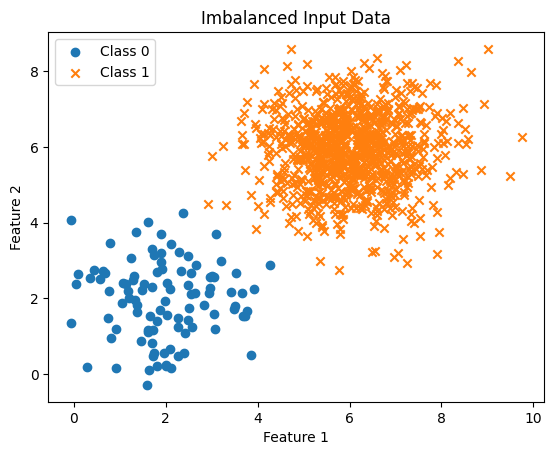

In [3]:
plt.figure()

plt.scatter(class_0[:, 0], class_0[:, 1], marker='o', label='Class 0')

plt.scatter(class_1[:, 0], class_1[:, 1], marker='x', label='Class 1')

plt.title("Imbalanced Input Data")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()

plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=5
)

In [5]:
params = {
    'n_estimators': 100,
    'max_depth': 4,
    'random_state': 0
}

classifier = ExtraTreesClassifier(**params)

classifier.fit(X_train, y_train)

ExtraTreesClassifier(max_depth=4, random_state=0)

In [6]:
y_test_pred = classifier.predict(X_test)

In [7]:
class_names = ['Class-0', 'Class-1']

print("\n" + "#" * 50)
print("\nClassifier performance on test dataset\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names
    )
)

print("\n" + "#" * 50)


##################################################

Classifier performance on test dataset

              precision    recall  f1-score   support

     Class-0       1.00      1.00      1.00        16
     Class-1       1.00      1.00      1.00       234

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250


##################################################


In [8]:
def visualize_classifier(classifier, X, y, title):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    step_size = 0.01
    x_values, y_values = np.meshgrid(
        np.arange(x_min, x_max, step_size),
        np.arange(y_min, y_max, step_size)
    )
    mesh_output = classifier.predict(
        np.c_[x_values.ravel(), y_values.ravel()]
    )
    mesh_output = mesh_output.reshape(x_values.shape)
    plt.figure()
    plt.pcolormesh(x_values, y_values, mesh_output, shading='auto')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

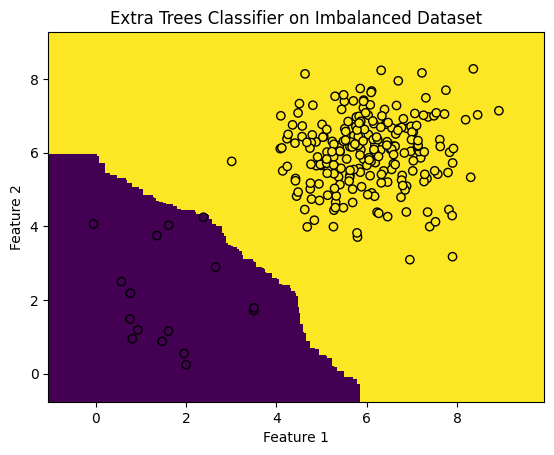

In [9]:
visualize_classifier(
    classifier,
    X_test,
    y_test,
    "Extra Trees Classifier on Imbalanced Dataset"
)

In [10]:
params = {
    'n_estimators': 100,
    'max_depth': 4,
    'random_state': 0,
    'class_weight': 'balanced'
}

classifier_balanced = ExtraTreesClassifier(**params)

classifier_balanced.fit(X_train, y_train)

ExtraTreesClassifier(class_weight='balanced', max_depth=4, random_state=0)

In [11]:
y_test_pred_balanced = classifier_balanced.predict(X_test)

In [12]:
print("\n" + "#" * 50)
print("\nClassifier performance with balanced class weight\n")

print(
    classification_report(
        y_test,
        y_test_pred_balanced,
        target_names=class_names
    )
)

print("\n" + "#" * 50)


##################################################

Classifier performance with balanced class weight

              precision    recall  f1-score   support

     Class-0       1.00      1.00      1.00        16
     Class-1       1.00      1.00      1.00       234

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250


##################################################


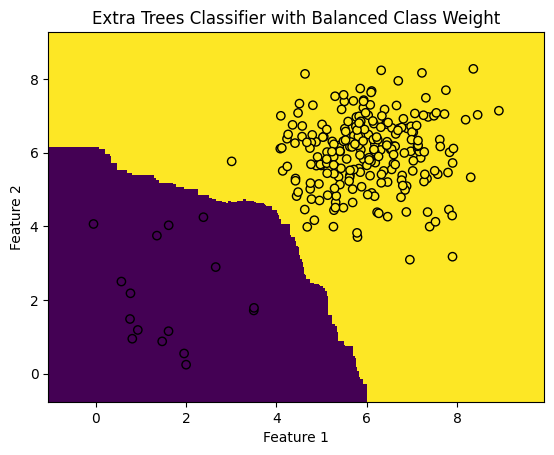

In [13]:
visualize_classifier(
    classifier_balanced,
    X_test,
    y_test,
    "Extra Trees Classifier with Balanced Class Weight"
)